# Test implementation of WASF-GA and interactive WASF-GA

In [5]:
from desdeo.emo.operators.selection import ReferenceVectorOptions
from desdeo.emo.options.generator import LHSGeneratorOptions
from desdeo.emo.options.repair import ClipRepairOptions
from desdeo.emo.options.selection import WASFGASelectorOptions
from desdeo.emo.options.termination import MaxGenerationsTerminatorOptions
from docs.explanation.AAC_interactive_EMO.utils import create_problem, get_default_ea_parameters
from rich.pretty import pprint  # Just for pretty printing

from desdeo.emo import (
    algorithms,
    crossover,
    generator,
    mutation,
    other,
    preference_handling,
    repair,
    scalar_selection,
    selection,
    templates,
    termination,
)

pprint(algorithms.wasfga_options())

name="DTLZ2"
n_obj=3
reference_point = [0.5, 0.5, 0.5]

problem = create_problem(name, n_obj)
n_obj = len(problem.objectives)
symbols = [f"{x.symbol}" for x in problem.objectives]
reference_points = []
pop_size, n_gen, pymoo_layers = get_default_ea_parameters(problem.name, n_obj)


wasfga_opts = algorithms.wasfga_options()

wasfga_opts.template.repair = ClipRepairOptions(name="ClipRepair")
wasfga_opts.template.generator=LHSGeneratorOptions(n_points=pop_size, name='LHSGenerator')
wasfga_opts.template.termination = MaxGenerationsTerminatorOptions(name='MaxGenerationsTerminator', max_generations=n_gen)        
wasfga_opts.template.selection = WASFGASelectorOptions(
    name='WASFGASelector',
    reference_vector_options=ReferenceVectorOptions(
        creation_type="multi_layer",
        pymoo_layers=pymoo_layers,
    ),
)

preferences_wasfga = preference_handling.ReferencePointOptions(
    preference=dict(zip(symbols, reference_point)),
    method="WASFGA",
)

wasfga_opts.preference = preferences_wasfga

wasfga, extras_wasfga = algorithms.emo_constructor(
    emo_options=wasfga_opts,
    problem=problem      
)

result_wasfga = wasfga()

print("WASF-GA Results:")
pprint(result_wasfga.optimal_outputs)


EMOOptions(
│   preference=None,
│   template=Template1Options(
│   │   crossover=SimulatedBinaryCrossoverOptions(
│   │   │   name='SimulatedBinaryCrossover',
│   │   │   xover_probability=0.5,
│   │   │   xover_distribution=30.0
│   │   ),
│   │   mutation=BoundedPolynomialMutationOptions(
│   │   │   name='BoundedPolynomialMutation',
│   │   │   mutation_probability=None,
│   │   │   distribution_index=20.0
│   │   ),
│   │   selection=WASFGASelectorOptions(
│   │   │   name='WASFGASelector',
│   │   │   reference_vector_options=ReferenceVectorOptions(
│   │   │   │   adaptation_frequency=0,
│   │   │   │   creation_type='simplex',
│   │   │   │   vector_type='planar',
│   │   │   │   lattice_resolution=None,
│   │   │   │   number_of_vectors=100,
│   │   │   │   pymoo_layers=None,
│   │   │   │   adaptation_distance=0.2,
│   │   │   │   reference_point=None,
│   │   │   │   preferred_solutions=None,
│   │   │   │   non_preferred_solutions=None,
│   │   │   │   preferred_ranges=None
│   │   │   ),
│   │   │   reference_point=None
│   │   ),
│   │   termination=MaxGenerationsTerminatorOptions(name='MaxGenerationsTerminator', max_generations=100),
│   │   generator=LHSGeneratorOptions(n_points=100, name='LHSGenerator'),
│   │   repair=NoRepairOptions(name='NoRepair'),
│   │   use_archive=True,
│   │   seed=42,
│   │   verbosity=2,
│   │   algorithm_name='WASFGA',
│   │   name='Template1'
│   )
)

✅ Created DTLZ2 with 24 vars and 3 objectives.
WASF-GA Results:


shape: (154, 6)
┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ f_1      ┆ f_2      ┆ f_3      ┆ f_1_min  ┆ f_2_min  ┆ f_3_min  │
│ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ 1.110706 ┆ 1.620866 ┆ 0.0      ┆ 1.110706 ┆ 1.620866 ┆ 0.0      │
│ 1.356825 ┆ 0.0      ┆ 0.0      ┆ 1.356825 ┆ 0.0      ┆ 0.0      │
│ 1.415302 ┆ 0.0      ┆ 0.0      ┆ 1.415302 ┆ 0.0      ┆ 0.0      │
│ 1.293589 ┆ 0.0      ┆ 0.0      ┆ 1.293589 ┆ 0.0      ┆ 0.0      │
│ 1.291237 ┆ 0.0      ┆ 0.0      ┆ 1.291237 ┆ 0.0      ┆ 0.0      │
│ …        ┆ …        ┆ …        ┆ …        ┆ …        ┆ …        │
│ 0.539954 ┆ 0.586595 ┆ 0.604134 ┆ 0.539954 ┆ 0.586595 ┆ 0.604134 │
│ 0.537329 ┆ 0.569815 ┆ 0.622477 ┆ 0.537329 ┆ 0.569815 ┆ 0.622477 │
│ 0.53249  ┆ 0.59891  ┆ 0.598883 ┆ 0.53249  ┆ 0.59891  ┆ 0.598883 │
│ 0.527797 ┆ 0.612363 ┆ 0.589866 ┆ 0.527797 ┆ 0.612363 ┆ 0.589866 │
│ 0.529815 ┆ 0.589574 ┆ 0.610575 ┆ 0.529815 ┆ 0.589574 ┆ 0.610575 │
└──────────┴──────────┴──────────┴──────────┴──────────┴──────────┘

<Figure size 640x480 with 0 Axes>

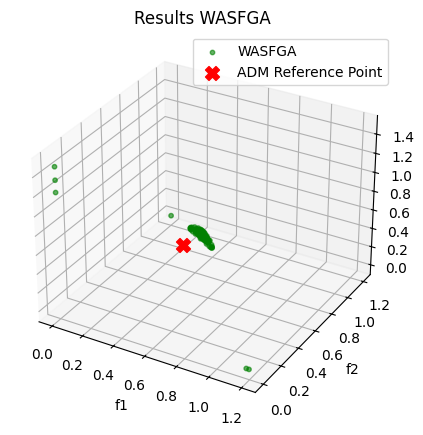

In [6]:
import matplotlib.pyplot as plt
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

data_wasfga = result_wasfga.optimal_outputs.to_pandas()

# Convert to numpy array for PyMOO
objectives_array = data_wasfga.iloc[:, :n_obj].values

# Perform non-dominated sorting
nds = NonDominatedSorting()
fronts = nds.do(objectives_array)

# Get the first front (non-dominated solutions)
first_front_indices = fronts[0]
data_wasfga = data_wasfga.iloc[first_front_indices]


plt.clf()
fig = plt.figure(figsize=(12, 5))
            
ax = fig.add_subplot(121, projection='3d')
ax.scatter(data_wasfga.iloc[:,0], data_wasfga.iloc[:,1],
            data_wasfga.iloc[:,2], c='green', s=10, alpha=0.6, label='WASFGA')

ax.scatter(reference_point[0], reference_point[1], reference_point[2], 
         c='red', s=100, marker='X', label='ADM Reference Point')
ax.set_title(f'Results WASFGA')
ax.set_xlabel('f1')
ax.set_ylabel('f2')
ax.set_zlabel('f3')
ax.legend()